# Lab 03: Statistics Review I

**Week:** 2
**Type:** Guided
**Corresponding working sessions:** `working-sessions/statistics/`
**Estimated time:** 50–65 minutes
**Dataset:** Titanic — 891 passengers with survival outcome, passenger class, sex, age, and fare

---
### Learning Objectives
By the end of this lab you will be able to:
- Calculate simple and conditional probabilities on real data
- Summarize distributions with central tendency and dispersion measures
- Identify distribution shape from skewness and the mean-median relationship
- Compute and interpret a Pearson correlation matrix

---
### A note before you start

This lab is guided — every exercise has a scaffold showing you what to fill in.
If you get stuck at any point, your working session notebooks in `working-sessions/statistics/`
are open for reference. Use them. That is what they are there for.

Run the cells in order. Each section builds on the one before it.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tkh_utils import (
    PALETTE, FONT, base_layout,
    check_answer, make_answer_key,
    make_grading_summary
)
from tkh_utils import load_titanic

In [3]:
_ak = make_answer_key({
    'q1': 'C',
    'q2': 'A',
    'q3': 'D',
    'q4': 'B',
})

---
## Dataset: Titanic

We are using the Titanic dataset — one of the most-studied datasets in data science.
It records 891 passengers from the 1912 voyage, including whether they survived,
what class they travelled in, their sex, age, and the fare they paid.

In [4]:
titanic = load_titanic()
print("Shape:", titanic.shape)
print()
titanic.head()

Shape: (891, 15)



,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


**Key columns for this lab:**

| Column | Type | Description |
|--------|------|-------------|
| `survived` | int | 1 = survived, 0 = did not survive |
| `pclass` | int | Passenger class (1, 2, or 3) |
| `sex` | str | `'male'` or `'female'` |
| `age` | float | Age in years (177 missing values) |
| `fare` | float | Ticket fare in British pounds |

Note: `age` has missing values — use `.dropna()` when working with it.

---
## Section A — Conceptual Questions

For each question below, replace `"___"` with your answer (`"A"`, `"B"`, `"C"`, or `"D"`).
Run the cell after filling in your answer — you will get immediate feedback.

In [6]:
# Question 1
# A fair six-sided die is rolled. Given that the result is even,
# what is the probability the result is also greater than 3?
#
#   A) 1/6
#   B) 1/3
#   C) 2/3
#   D) 1/2

q1_answer = "C"  # replace ___ with A, B, C, or D

assert q1_answer != "___", "Don't forget to fill in your answer."
assert check_answer(q1_answer, _ak['q1']), \
    "Not quite. The even outcomes are {2, 4, 6}. Of those, how many are greater than 3? " \
    "Revisit working-sessions/statistics/02_conditional_probability_independence.ipynb"
print("\u2713 Question 1 correct!")

✓ Question 1 correct!


In [7]:
# Question 2
# A real-estate analyst wants to summarize the typical home price
# in a neighborhood where most homes sell for $250,000 to $400,000,
# but three mansions sold for over $5 million each.
# Which measure of central tendency should she report?
#
#   A) Median
#   B) Mean
#   C) Mode
#   D) Range

q2_answer = "A"  # replace ___ with A, B, C, or D

assert q2_answer != "___", "Don't forget to fill in your answer."
assert check_answer(q2_answer, _ak['q2']), \
    "Not quite. The three mansion sales will pull the mean far above what a typical buyer pays. " \
    "Revisit working-sessions/statistics/04_central_tendency.ipynb"
print("\u2713 Question 2 correct!")

✓ Question 2 correct!


In [8]:
# Question 3
# A dataset has a mean of 45 and a median of 38.
# Which statement best describes its shape?
#
#   A) The distribution is symmetric
#   B) The distribution is left-skewed with a long tail toward lower values
#   C) The distribution is bimodal
#   D) The distribution is right-skewed with a long tail toward higher values

q3_answer = "D"  # replace ___ with A, B, C, or D

assert q3_answer != "___", "Don't forget to fill in your answer."
assert check_answer(q3_answer, _ak['q3']), \
    "Not quite. Think about which direction the mean is being pulled relative to the median. " \
    "Revisit working-sessions/statistics/06_shape_of_distributions.ipynb"
print("\u2713 Question 3 correct!")

✓ Question 3 correct!


In [9]:
# Question 4
# Two researchers find a Pearson r of 0.80 between hours of screen time
# and teenage anxiety scores. A journalist writes: "Screen time CAUSES
# anxiety — it explains 80% of the variation."
# Which statement correctly identifies the errors in the journalist's claim?
#
#   A) r = 0.80 is too low to be meaningful; the study should be dismissed
#   B) Correlation does not establish causation, and r squared (not r) equals
#      the proportion of variance explained, which is 0.64 (64%), not 80%
#   C) The journalist should have used Spearman rho instead of Pearson r
#   D) r = 0.80 means the relationship is perfectly linear

q4_answer = "B"  # replace ___ with A, B, C, or D

assert q4_answer != "___", "Don't forget to fill in your answer."
assert check_answer(q4_answer, _ak['q4']), \
    "Not quite. There are two errors: one about causation and one about r vs r squared. " \
    "Revisit working-sessions/statistics/07_correlation_covariance.ipynb"
print("\u2713 Question 4 correct!")

✓ Question 4 correct!


---
## Section B — Code Completion

Fill in each `___` to complete the code. There may be more than one blank per exercise.
Run the cell to check your work — the assert statement will tell you if something is wrong.

In [10]:
# Exercise B1 — Basic probability
# Calculate the probability that a randomly selected passenger survived,
# and the probability they did NOT survive (the complement).

n_passengers = len(titanic)               # total outcomes
n_survived   = titanic["survived"].sum()         # favorable outcomes: count the 1s

p_survived     = n_survived / n_passengers               # P(survived) = k / n
p_not_survived = 1 - p_survived               # complement rule: 1 - P(survived)

# --- check ---
assert isinstance(p_survived, float), \
    "p_survived should be a float — check your division"
assert abs(p_survived - 0.3838) < 0.01, \
    ("p_survived should be near 0.38 — "
     "revisit working-sessions/statistics/01_basic_probability.ipynb")
assert abs(p_survived + p_not_survived - 1.0) < 1e-10, \
    "p_survived + p_not_survived must equal 1.0 — that is the complement rule"
print(f"\u2713 P(survived) = {p_survived:.4f},  P(not survived) = {p_not_survived:.4f}")

✓ P(survived) = 0.3838,  P(not survived) = 0.6162


In [11]:
# Exercise B2 — Conditional probability
# Was survival independent of sex on the Titanic?
# Calculate P(survived | female) and P(survived | male),
# then compare them to P(survived) to test for independence.

# Subset to female passengers, then take the mean of 'survived'
female_passengers    = titanic[titanic["sex"] == "female"]
p_survived_if_female = female_passengers["survived"].mean()  # mean of a 0/1 column = proportion

# Repeat for male passengers
male_passengers      = titanic[titanic["sex"] == "male"]
p_survived_if_male   = male_passengers["survived"].mean()    # same idea

# --- check ---
assert abs(p_survived_if_female - 0.742) < 0.01, \
    ("P(survived|female) should be near 0.74 — "
     "revisit working-sessions/statistics/02_conditional_probability_independence.ipynb")
assert abs(p_survived_if_male - 0.189) < 0.01, \
    ("P(survived|male) should be near 0.19 — "
     "revisit working-sessions/statistics/02_conditional_probability_independence.ipynb")
assert p_survived_if_female > p_survived, \
    "Survival was higher for women — check your female subset"

print(f"P(survived):          {p_survived:.4f}")
print(f"P(survived | female): {p_survived_if_female:.4f}")
print(f"P(survived | male):   {p_survived_if_male:.4f}")
print()
print("Are survival and sex independent?",
      "No" if abs(p_survived_if_female - p_survived) > 0.05 else "Yes")

P(survived):          0.3838
P(survived | female): 0.7420
P(survived | male):   0.1889

Are survival and sex independent? No


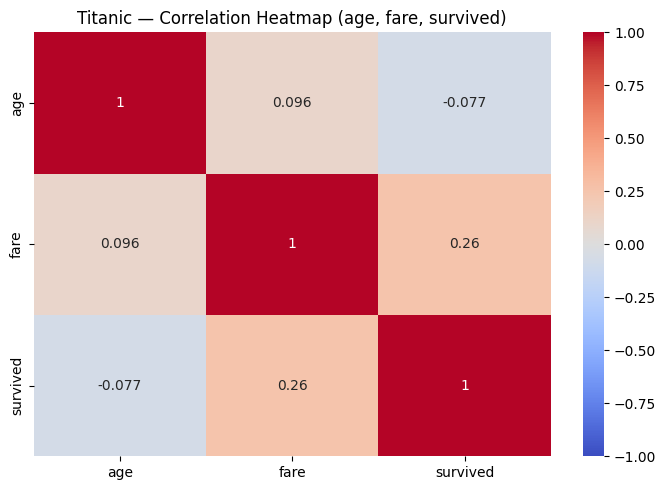

✓ Correlation heatmap created!


In [12]:
# Exercise B3 — Correlation heatmap
# Compute a correlation matrix for age, fare, and survived,
# then visualize it as a heatmap.

# Step 1: select the three columns and compute the correlation matrix
corr_cols   = ['age', 'fare', 'survived']
corr_matrix = titanic[corr_cols].corr()          # hint: .corr()

# Step 2: plot the heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(                    # hint: heatmap
    corr_matrix,
    annot=True,              # show correlation values inside the cells
    cmap="coolwarm",               # hint: 'coolwarm'
    vmin=-1, vmax=1,
    ax=ax
)
ax.set_title('Titanic — Correlation Heatmap (age, fare, survived)')
plt.tight_layout()
plt.show()

# --- check ---
assert isinstance(corr_matrix, pd.DataFrame), \
    "corr_matrix should be a DataFrame — check your .corr() call"
assert corr_matrix.shape == (3, 3), \
    "corr_matrix should be 3x3 — one row/column per selected column"
assert abs(corr_matrix.loc['fare', 'survived'] - 0.257) < 0.01, \
    ("fare-survived correlation should be near 0.26 — "
     "revisit working-sessions/statistics/07_correlation_covariance.ipynb")
print("\u2713 Correlation heatmap created!")

---
## Section C — Guided Function

Write a function called `survival_profile(df, pclass)` that takes:
- `df`: the Titanic DataFrame
- `pclass`: a passenger class (1, 2, or 3)

And returns a dictionary with these keys:

| Key | Value |
|-----|-------|
| `'n'` | Number of passengers in this class |
| `'survival_rate'` | P(survived \| pclass) rounded to 4 decimal places |
| `'avg_fare'` | Mean fare for this class, rounded to 2 decimal places |
| `'complement'` | 1 - survival_rate (probability of NOT surviving) |

After writing the function, call it once for each class and store the results
in a list called `profiles`. Then print each result.

**Guidance:** Use Boolean indexing to filter to the requested class.
The survival rate is the mean of the `'survived'` column in the subset.

In [13]:
def survival_profile(df, pclass):
    # Step 1: filter the DataFrame to the requested passenger class
    subset = df[df["pclass"] == pclass]

    # Step 2: calculate the required statistics
    n             = len(subset)
    survival_rate = round(subset["survived"].mean(), 4)
    avg_fare      = round(subset["fare"].mean(), 2)
    complement    = round(1 - survival_rate, 4)

    # Step 3: return as a dictionary
    return {
        'n':             n,
        'survival_rate': survival_rate,
        'avg_fare':      avg_fare,
        'complement':    complement,
    }


# Call the function for each class
profiles = [survival_profile(titanic, cls) for cls in [1, 2, 3]]

for cls, profile in zip([1, 2, 3], profiles):
    print(f"Class {cls}:", profile)

Class 1: {'n': 216, 'survival_rate': np.float64(0.6296), 'avg_fare': np.float64(84.15), 'complement': np.float64(0.3704)}
Class 2: {'n': 184, 'survival_rate': np.float64(0.4728), 'avg_fare': np.float64(20.66), 'complement': np.float64(0.5272)}
Class 3: {'n': 491, 'survival_rate': np.float64(0.2424), 'avg_fare': np.float64(13.68), 'complement': np.float64(0.7576)}


In [14]:
# --- Section C checks ---
assert callable(survival_profile), \
    "survival_profile should be a function"

result_1 = survival_profile(titanic, 1)
result_3 = survival_profile(titanic, 3)

assert isinstance(result_1, dict), \
    "survival_profile should return a dictionary"
assert set(result_1.keys()) == {'n', 'survival_rate', 'avg_fare', 'complement'}, \
    "Dictionary must have exactly: n, survival_rate, avg_fare, complement"

assert result_1['n'] == 216, \
    ("Class 1 should have 216 passengers — "
     "check your Boolean filter in working-sessions/statistics/01_basic_probability.ipynb")
assert abs(result_1['survival_rate'] - 0.6296) < 0.001, \
    ("Class 1 survival rate should be near 0.63 — "
     "revisit working-sessions/statistics/02_conditional_probability_independence.ipynb")
assert result_3['n'] == 491, \
    "Class 3 should have 491 passengers"
assert abs(result_3['survival_rate'] - 0.2424) < 0.001, \
    "Class 3 survival rate should be near 0.24"

for cls, profile in zip([1, 2, 3], profiles):
    assert abs(profile['survival_rate'] + profile['complement'] - 1.0) < 1e-9, \
        f"Class {cls}: survival_rate + complement must equal 1.0"

print("\u2713 Section C complete!")
print()
print("Summary:")
for cls, profile in zip([1, 2, 3], profiles):
    print(f"  Class {cls} — {profile['n']} passengers, "
          f"survival rate: {profile['survival_rate']:.1%}, "
          f"avg fare: \u00a3{profile['avg_fare']:.2f}")

✓ Section C complete!

Summary:
  Class 1 — 216 passengers, survival rate: 63.0%, avg fare: £84.15
  Class 2 — 184 passengers, survival rate: 47.3%, avg fare: £20.66
  Class 3 — 491 passengers, survival rate: 24.2%, avg fare: £13.68


---
## Section D — Interpretation

These questions are for reflection. Edit the markdown cells below each question
to write your response. There is no single right answer — we are looking for
thoughtful engagement with the concepts.

**Question D1:** The survival rate for female passengers (74.2%) is dramatically
higher than for male passengers (18.9%). Does this prove that being female
*caused* passengers to survive? What other explanation could account for
this pattern in the data?

It does not prove that being female caused passengers to survive. one mayor explanation could be the policy of women and children first.

**Question D2:** The mean Titanic fare is approximately £32.20 and the median
fare is approximately £14.45. The standard deviation is approximately £49.69,
which is larger than the mean itself. What does this combination of statistics
tell you about the shape of the fare distribution? Which summary statistic
would you report to a journalist who asked "what did a typical ticket cost?"

It seems to be right-skewed because the mean is way larger than the median. The large deviation suggests there is a lot of variability and some very expensive tickets as outliers. The statistic that I would report would be the median because it represents a typical passenger's fare.

**Question D3:** A colleague looks at the correlation heatmap from Exercise B3
and says: "Age and fare are barely correlated (r near 0.10), so age is useless
for understanding anything on this dataset." Do you agree? What would you
investigate next before accepting or rejecting that claim?

No because a low correlation only means there there isn't a strong connection between age and fare, but age could be related to other factors. Before accepting or rejecting the claim, I would check the connections between age and other factors.

---
## Self-Grading Summary

Run the cell below when you are ready to check your full score.
Fix any failing checks and re-run until everything passes.

In [15]:
make_grading_summary([
    (q1_answer, _ak['q1'], "Q1: Conditional probability P(A|B)"),
    (q2_answer, _ak['q2'], "Q2: Choosing the right measure of center"),
    (q3_answer, _ak['q3'], "Q3: Identifying distribution shape from mean vs median"),
    (q4_answer, _ak['q4'], "Q4: Correlation vs causation; r vs r squared"),
], total=4)
print("Section B & C: check \u2713 marks above")
print("Section D: for your own reflection")

Section A Results:
✓ Q1: Conditional probability P(A|B)
✓ Q2: Choosing the right measure of center
✓ Q3: Identifying distribution shape from mean vs median
✓ Q4: Correlation vs causation; r vs r squared

Score: 4/4
----------------------------------------
🎉 Perfect score on Section A!

Section B & C: check ✓ marks above
Section D: for your own reflection
Section B & C: check ✓ marks above
Section D: for your own reflection
